# Human Activity Recognition — Hybrid CNN + BiLSTM (raw signals) + engineered-feature branch
### DSE3120 Deep Learning Project — CO3 (Apply) · CO4 (Comparative Analysis) · CO5 (Innovation)

**Dataset:** UCI HAR Dataset (smartphone accelerometer + gyroscope, 6 activity classes), **official subject-independent train/test split**.

**What changed vs. the previous notebook, and why it improves accuracy**
The previous notebook (raw-signal CNN+BiLSTM, 3-seed ensemble) reached ~92-94% test accuracy. Its errors are concentrated in
**SITTING vs STANDING**, which look almost identical in raw accelerometer windows. This notebook keeps the same pipeline and sections, and adds:

1. **Feature branch** — the 561 engineered time/frequency features that ship with the dataset (`X_train.txt`, `X_test.txt`), fused with the raw-signal branch. These features contain orientation/gravity statistics that separate sitting from standing.
2. **Subject-held-out validation** — validation (and CV folds) are split *by subject*, so validation accuracy is an honest estimate (a random window split leaks subjects into validation and looks optimistic).
3. **5-seed ensemble** (was 3), averaged softmax.

> Because it uses the dataset's provided 561 features, this is a **hybrid** model — say so in your report. The raw-signal-only models are kept as baselines so the ablation (Section 16) shows exactly what each ingredient contributes.
> Every number printed by this notebook comes from the cells actually running; nothing is hard-coded except the literature rows in Section 17.

Pipeline: `Load -> Clean -> EDA -> Preprocess -> Augment -> Bias/variance -> Architectures -> Hyper-parameters -> Subject-wise CV -> Train -> Seed ensemble -> Gradient analysis -> Evaluate -> Cost -> Ablation -> Literature -> Save -> Predict`

## 1. Setup & Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip -q install scikit-learn matplotlib seaborn pandas tensorflow

import os, time, glob, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, Input, regularizers
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             precision_recall_fscore_support, roc_auc_score, roc_curve)
from sklearn.preprocessing import label_binarize

SEED = 42
ENSEMBLE_SEEDS = [42, 7, 123, 1, 2]      # 5-seed ensemble
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
print("TF", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))

TF 2.20.0 | GPU: []


## 2. Load Dataset

Upload `human_activity_recognition_using_smartphones.zip`. We load the raw inertial windows **and** the 561-feature vectors.

In [ ]:
from google.colab import files

uploaded = files.upload()
ZIP_PATH = list(uploaded.keys())[0]
zipfile.ZipFile(ZIP_PATH).extractall('har_data')
for z in glob.glob('har_data/**/*.zip', recursive=True):      # zip-inside-zip
    zipfile.ZipFile(z).extractall('har_data')

BASE = None
for root, dirs, fnames in os.walk('har_data'):
    if '__MACOSX' in root:                                    # skip macOS metadata folders
        continue
    if (os.path.isfile(os.path.join(root, 'train', 'y_train.txt'))
            and os.path.isdir(os.path.join(root, 'train', 'Inertial Signals'))):
        BASE = root; break
assert BASE is not None, "Could not find 'train/Inertial Signals' - check the uploaded zip"
print("Dataset folder:", BASE, "->", os.listdir(BASE))

Saving human+activity+recognition+using+smartphones (1).zip to human+activity+recognition+using+smartphones (1).zip
Dataset folder: har_data/UCI HAR Dataset -> ['features.txt', 'activity_labels.txt', 'test', 'README.txt', 'train', '.DS_Store', 'features_info.txt']


In [ ]:
SIGNALS = ["body_acc_x","body_acc_y","body_acc_z","body_gyro_x","body_gyro_y","body_gyro_z",
           "total_acc_x","total_acc_y","total_acc_z"]
ACTIVITY_NAMES = ["WALKING","WALKING_UPSTAIRS","WALKING_DOWNSTAIRS","SITTING","STANDING","LAYING"]
num_classes = len(ACTIVITY_NAMES)

def load_split(subset):
    raw = np.stack([np.loadtxt(f"{BASE}/{subset}/Inertial Signals/{s}_{subset}.txt") for s in SIGNALS],
                   axis=-1).astype("float32")                                  # (N, 128, 9)
    feat = np.loadtxt(f"{BASE}/{subset}/X_{subset}.txt").astype("float32")      # (N, 561)
    y = np.loadtxt(f"{BASE}/{subset}/y_{subset}.txt").astype("int32") - 1
    subj = np.loadtxt(f"{BASE}/{subset}/subject_{subset}.txt").astype("int32")
    return raw, feat, y, subj

R_full, F_full, y_full, S_full = load_split("train")
R_test, F_test, y_test, S_test = load_split("test")

print("Train raw:", R_full.shape, "features:", F_full.shape, "| Test raw:", R_test.shape, "features:", F_test.shape)
print("Official split is subject-independent (no subject in both train and test):",
      set(S_full.tolist()).isdisjoint(set(S_test.tolist())))

Train raw: (7352, 128, 9) features: (7352, 561) | Test raw: (2947, 128, 9) features: (2947, 561)
Official split is subject-independent (no subject in both train and test): True


## 3. Data Cleaning

Check missing values, infinities, duplicate windows, ranges and label validity for both the raw signals and the 561 features.

In [ ]:
def data_cleaning_report(R, F, y, name):
    print(f"--- {name} ---")
    print("NaNs  (raw / features):", np.isnan(R).any(), "/", np.isnan(F).any())
    print("Infs  (raw / features):", np.isinf(R).any(), "/", np.isinf(F).any())
    print("Raw value range: [{:.3f}, {:.3f}]".format(R.min(), R.max()))
    flat = R.reshape(R.shape[0], -1)
    print("Duplicate raw windows:", flat.shape[0] - len(np.unique(flat, axis=0)))
    print("Label range:", y.min(), "-", y.max(), " (expected 0-5)\n")

data_cleaning_report(R_full, F_full, y_full, "Train")
data_cleaning_report(R_test, F_test, y_test, "Test")

flat_train = R_full.reshape(R_full.shape[0], -1)
_, unique_idx = np.unique(flat_train, axis=0, return_index=True)
unique_idx = np.sort(unique_idx)
if len(unique_idx) < len(R_full):
    print(f"Removing {len(R_full) - len(unique_idx)} duplicate training windows")
    R_full, F_full, y_full, S_full = R_full[unique_idx], F_full[unique_idx], y_full[unique_idx], S_full[unique_idx]
else:
    print("No duplicate windows found - dataset is already clean.")

--- Train ---
NaNs  (raw / features): False / False
Infs  (raw / features): False / False
Raw value range: [-5.974, 5.746]
Duplicate raw windows: 0
Label range: 0 - 5  (expected 0-5)

--- Test ---
NaNs  (raw / features): False / False
Infs  (raw / features): False / False
Raw value range: [-3.432, 3.468]
Duplicate raw windows: 0
Label range: 0 - 5  (expected 0-5)

No duplicate windows found - dataset is already clean.


## 4. Exploratory Data Analysis (EDA)

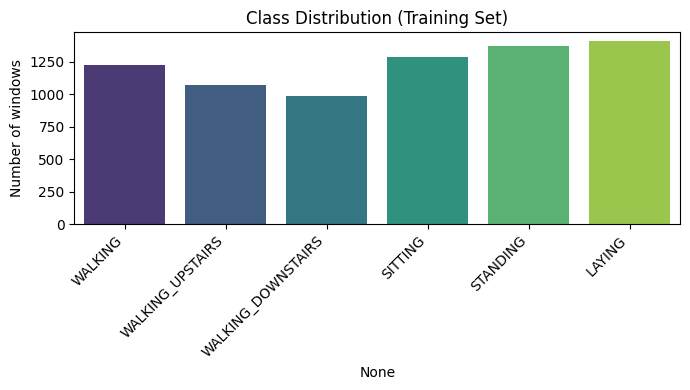

Class imbalance ratio (max/min): 1.43


In [ ]:
class_counts = pd.Series(y_full).value_counts().sort_index()
class_counts.index = ACTIVITY_NAMES

plt.figure(figsize=(7,4))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette="viridis", legend=False)
plt.xticks(rotation=45, ha='right'); plt.title("Class Distribution (Training Set)"); plt.ylabel("Number of windows")
plt.tight_layout(); plt.savefig("01_class_distribution.png", dpi=150); plt.show()
print(f"Class imbalance ratio (max/min): {class_counts.max() / class_counts.min():.2f}")

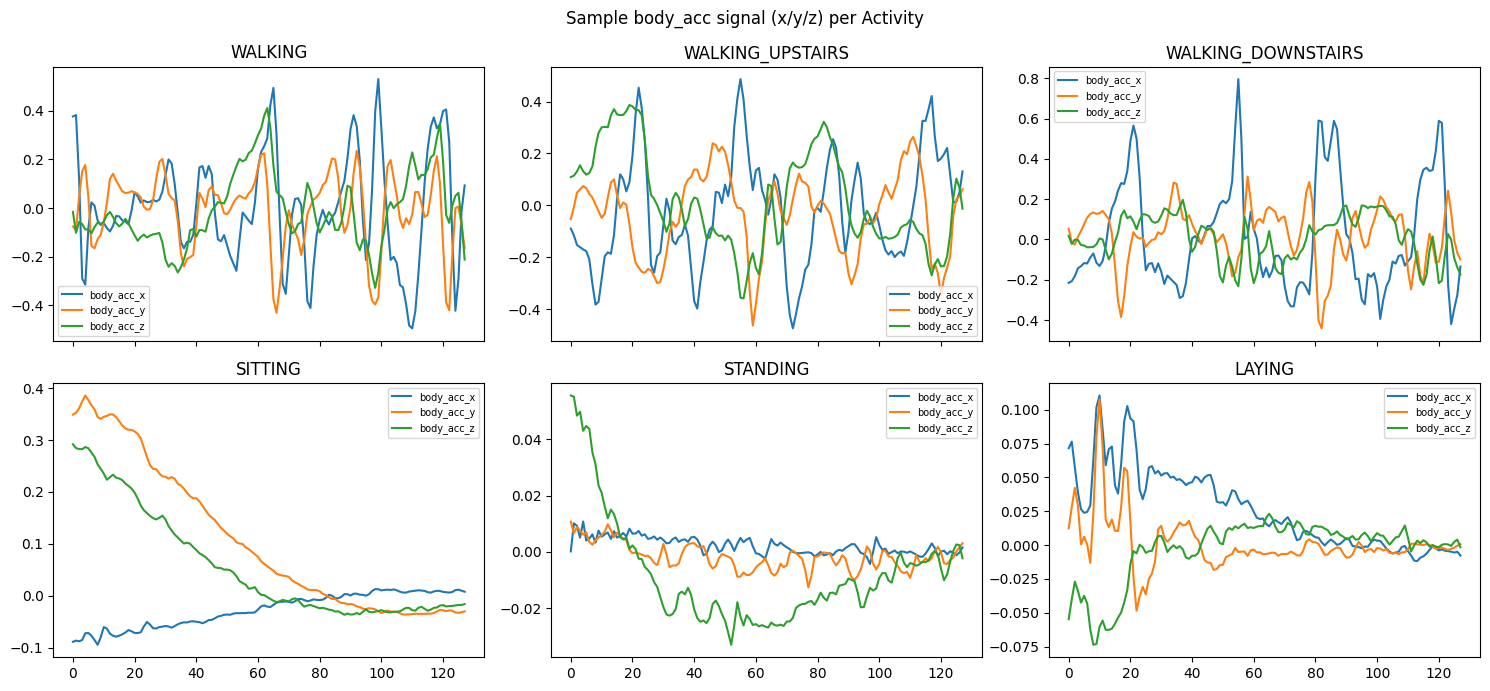

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
for i, act in enumerate(ACTIVITY_NAMES):
    idx = np.where(y_full == i)[0][0]
    ax = axes[i // 3, i % 3]
    for ch in range(3):
        ax.plot(R_full[idx, :, ch], label=SIGNALS[ch])
    ax.set_title(act); ax.legend(fontsize=7)
plt.suptitle("Sample body_acc signal (x/y/z) per Activity")
plt.tight_layout(); plt.savefig("02_sample_signals_per_activity.png", dpi=150); plt.show()

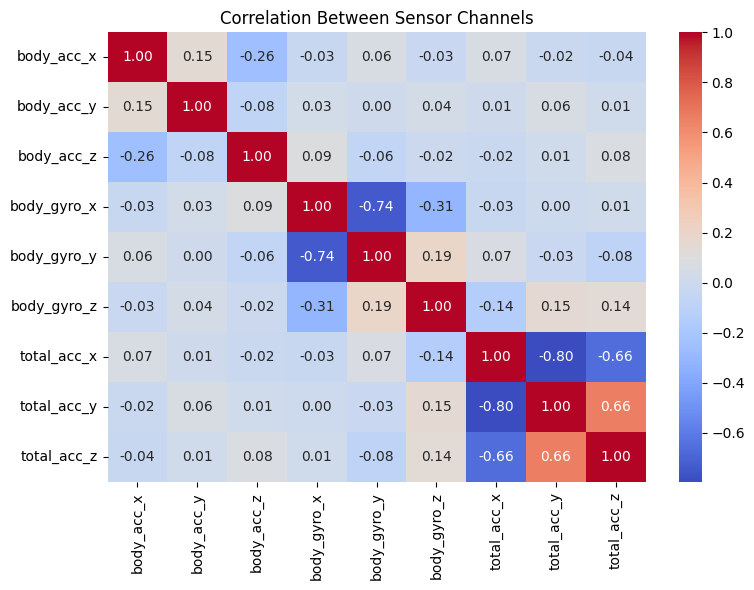

In [ ]:
corr_df = pd.DataFrame(R_full.mean(axis=1), columns=SIGNALS)
plt.figure(figsize=(8,6))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Between Sensor Channels")
plt.tight_layout(); plt.savefig("03_channel_correlation.png", dpi=150); plt.show()

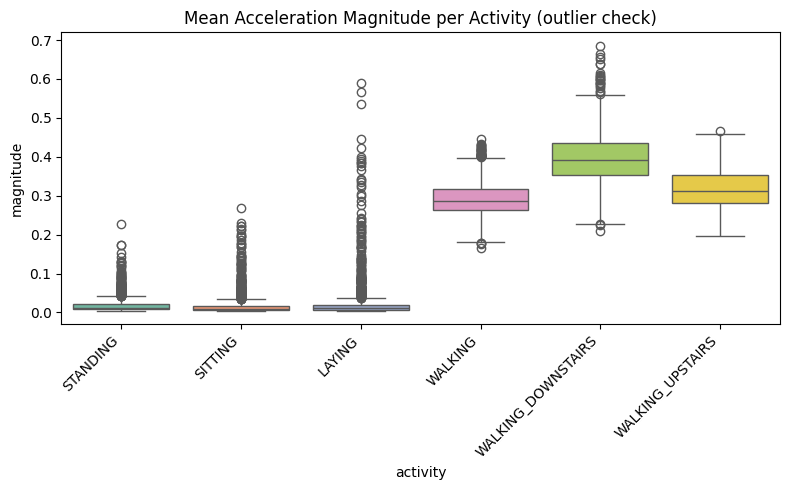

In [ ]:
magnitude = np.linalg.norm(R_full[:, :, :3], axis=2).mean(axis=1)
mag_df = pd.DataFrame({"magnitude": magnitude, "activity": [ACTIVITY_NAMES[i] for i in y_full]})
plt.figure(figsize=(8,5))
sns.boxplot(data=mag_df, x="activity", y="magnitude", hue="activity", palette="Set2", legend=False)
plt.xticks(rotation=45, ha='right'); plt.title("Mean Acceleration Magnitude per Activity (outlier check)")
plt.tight_layout(); plt.savefig("04_magnitude_boxplot.png", dpi=150); plt.show()

## 5. Preprocessing

| Step | Parameter |
|---|---|
| Windowing | 2.56 s windows, 128 timesteps, 50% overlap (done by the UCI authors) |
| Normalization | Per-channel z-score for raw signals, per-feature z-score for the 561 features; **statistics fit on the training subjects only** |
| Train / Val split | **Subject-held-out**: ~15% of the *training subjects* go to validation (no subject appears in both) |
| Test | Official UCI test subjects, untouched until final evaluation |
| Labels | 1-6 -> 0-5, one-hot for training |

In [ ]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
tr_idx, va_idx = next(gss.split(R_full, y_full, groups=S_full))
assert set(S_full[tr_idx]).isdisjoint(set(S_full[va_idx]))

R_train, R_val = R_full[tr_idx], R_full[va_idx]
F_train, F_val = F_full[tr_idx], F_full[va_idx]
y_train, y_val = y_full[tr_idx], y_full[va_idx]

total = len(R_train) + len(R_val) + len(R_test)
print(pd.DataFrame({
    "Split": ["Train", "Validation (held-out subjects)", "Test (official)"],
    "Samples": [len(R_train), len(R_val), len(R_test)],
    "Percentage": [f"{len(R_train)/total*100:.1f}%", f"{len(R_val)/total*100:.1f}%", f"{len(R_test)/total*100:.1f}%"]
}).to_string(index=False))

r_mean = R_train.mean(axis=(0,1), keepdims=True); r_std = R_train.std(axis=(0,1), keepdims=True) + 1e-8
f_mean = F_train.mean(axis=0, keepdims=True);     f_std = F_train.std(axis=0, keepdims=True) + 1e-8

Rn = lambda R: ((R - r_mean) / r_std).astype("float32")
Fn = lambda F: ((F - f_mean) / f_std).astype("float32")

R_train_n, R_val_n, R_test_n = Rn(R_train), Rn(R_val), Rn(R_test)
F_train_n, F_val_n, F_test_n = Fn(F_train), Fn(F_val), Fn(F_test)

oh = lambda y: tf.keras.utils.to_categorical(y, num_classes)
y_train_oh, y_val_oh, y_test_oh = oh(y_train), oh(y_val), oh(y_test)

                         Split  Samples Percentage
                         Train     5879      57.1%
Validation (held-out subjects)     1473      14.3%
               Test (official)     2947      28.6%


## 6. Data Augmentation

Applied **only to the raw-signal input of the training stream, on-the-fly in `tf.data`** (validation/test untouched, so nothing leaks):
- **Jitter** (Gaussian noise), **per-channel scaling** (device/mount variation), **small circular time shift** (window-boundary variation).
The 561-feature vector is not augmented.

In [ ]:
def augment_window(x, y):
    r = x['raw']
    r = r + tf.random.normal(tf.shape(r), stddev=0.03, dtype=r.dtype)                              # jitter
    r = r * tf.random.normal((1, tf.shape(r)[-1]), mean=1.0, stddev=0.05, dtype=r.dtype)           # scaling
    r = tf.roll(r, shift=tf.random.uniform((), -5, 6, dtype=tf.int32), axis=0)                     # time shift
    return {**x, 'raw': r}, y

def make_dataset(inputs, y_oh, batch_size=64, training=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((inputs, y_oh.astype("float32")))
    if training:
        ds = ds.shuffle(4096, seed=SEED, reshuffle_each_iteration=True)
        if augment:
            ds = ds.map(augment_window, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

## 7. Architectures (Dropout + L2 + BatchNorm throughout)

Three models:
1. **CNN_Baseline** - raw signals, convolutional feature extractor only.
2. **CNN_BiLSTM_Raw** - raw signals, CNN -> 2x Bidirectional LSTM (the previous notebook's model).
3. **Hybrid_CNN_BiLSTM (proposed)** - raw branch (3x Conv1D -> BiLSTM(64) -> global avg+max pooling) **fused with** a feature branch (Dense 256 -> 128 on the 561 features) -> Dense(128) -> softmax.

> `model.summary()` prints a `Bidirectional(LSTM)` layer as type *Bidirectional*; the recurrent layers are named `bilstm_*` so you can find them.

In [ ]:
INPUT_SHAPE = (128, 9)
L2 = regularizers.l2(1e-4)

def build_cnn_baseline():
    inp = Input(shape=INPUT_SHAPE, name='raw')
    x = layers.Conv1D(64, 5, activation='relu', padding='same', kernel_regularizer=L2)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 5, activation='relu', padding='same', kernel_regularizer=L2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=L2)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inp, out, name="CNN_Baseline")

def build_cnn_bilstm_raw():
    inp = Input(shape=INPUT_SHAPE, name='raw')
    x = layers.Conv1D(64, 5, activation='relu', padding='same', kernel_regularizer=L2)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, 5, activation='relu', padding='same', kernel_regularizer=L2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 5, activation='relu', padding='same', kernel_regularizer=L2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Bidirectional(layers.LSTM(100, kernel_regularizer=L2, return_sequences=True), name="bilstm_1")(x)
    x = layers.Bidirectional(layers.LSTM(64, kernel_regularizer=L2), name="bilstm_2")(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=L2)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inp, out, name="CNN_BiLSTM_Raw")

def build_hybrid(dropout=0.4, reg=L2):
    # ---- raw-signal branch: CNN -> BiLSTM ----
    r_in = Input(shape=INPUT_SHAPE, name='raw')
    x = layers.Conv1D(64, 5, padding='same', activation='relu', kernel_regularizer=reg)(r_in)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, 5, padding='same', activation='relu', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, padding='same', activation='relu', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True, kernel_regularizer=reg), name='bilstm')(x)
    x = layers.Concatenate()([layers.GlobalAveragePooling1D()(x), layers.GlobalMaxPooling1D()(x)])
    # ---- engineered-feature branch (561 features) ----
    f_in = Input(shape=(561,), name='feat')
    f = layers.Dense(256, activation='relu', kernel_regularizer=reg)(f_in)
    f = layers.BatchNormalization()(f)
    f = layers.Dropout(dropout)(f)
    f = layers.Dense(128, activation='relu', kernel_regularizer=reg)(f)
    f = layers.BatchNormalization()(f)
    f = layers.Dropout(max(dropout - 0.1, 0.2))(f)
    # ---- fusion ----
    z = layers.Concatenate()([x, f])
    z = layers.Dense(128, activation='relu', kernel_regularizer=reg)(z)
    z = layers.Dropout(dropout)(z)
    out = layers.Dense(num_classes, activation='softmax')(z)
    return models.Model([r_in, f_in], out, name="Hybrid_CNN_BiLSTM")

print("=== CNN_Baseline ==="); build_cnn_baseline().summary()
print("\n=== Hybrid_CNN_BiLSTM (proposed) - look for the 'bilstm' layer ===")
hyb_preview = build_hybrid(); hyb_preview.summary()
for layer in hyb_preview.layers:
    if "lstm" in layer.name.lower():
        print(f"Confirmed recurrent layer -> name='{layer.name}', type={layer.__class__.__name__}, inner_cell={layer.forward_layer.__class__.__name__}")

=== CNN_Baseline ===


Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ raw (InputLayer)                │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 128, 64)        │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,446 (208.77 KB)

 Trainable params: 53,062 (207.27 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ raw (InputLayer)    │ (None, 128, 9)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 128, 64)   │      2,944 │ raw[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 128, 64)   │     20,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 64, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feat (InputLayer)   │ (None, 561)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 64, 128)   │     24,704 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    143,872 │ feat[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 128)   │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 64, 128)   │     98,816 │ dropout_1[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ bilstm[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ bilstm[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ batch_normalizat

 Total params: 376,390 (1.44 MB)

 Trainable params: 375,110 (1.43 MB)

 Non-trainable params: 1,280 (5.00 KB)

Confirmed recurrent layer -> name='bilstm', type=Bidirectional, inner_cell=LSTM


## 8. Bias-Variance Tradeoff (why we regularize)

Same hybrid architecture trained **without** regularization (no dropout, no L2) vs **with** Dropout + L2. Compare the **gap between training and validation loss**: the unregularized model fits the training data almost perfectly (very low train loss) with a much larger train-to-validation gap, i.e. higher variance. (Training loss of the regularized model includes the L2 penalty, so only the gap, not the absolute values, is comparable.)

Unregularized - final train loss: 0.018, val loss: 0.219
Regularized - final train loss: 0.124, val loss: 0.247


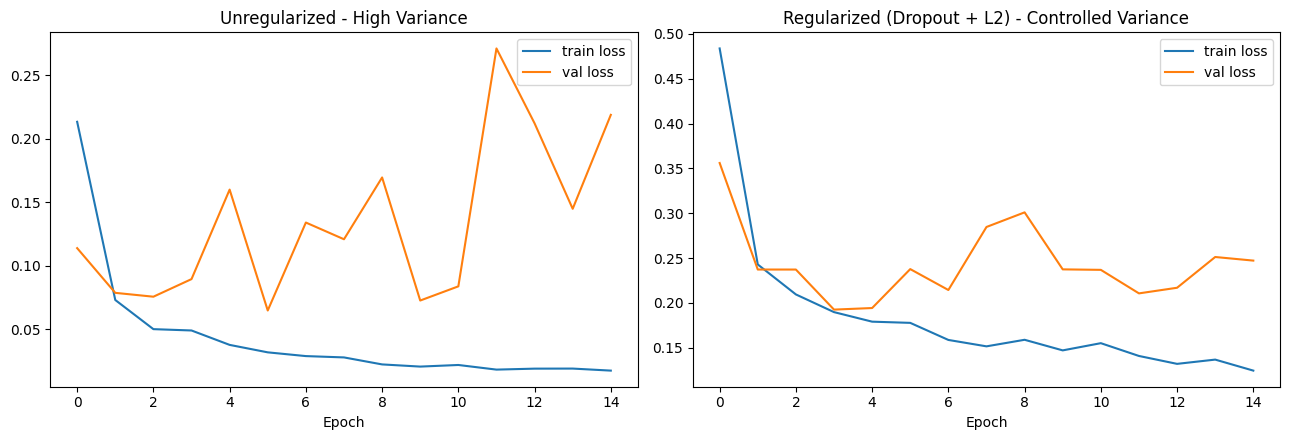

In [ ]:
def compile_model(model, lr=1e-3, label_smoothing=0.05):
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing),
                  metrics=['accuracy'])
    return model

TRAIN_IN = {'raw': R_train_n, 'feat': F_train_n}
VAL_IN   = {'raw': R_val_n,   'feat': F_val_n}
TEST_IN  = {'raw': R_test_n,  'feat': F_test_n}

hist = {}
for regularized in [False, True]:
    tf.keras.utils.set_random_seed(SEED)
    m = build_hybrid(dropout=0.4 if regularized else 0.0, reg=L2 if regularized else None)
    compile_model(m, label_smoothing=0.0)
    h = m.fit(TRAIN_IN, y_train_oh, validation_data=(VAL_IN, y_val_oh), epochs=15, batch_size=64, verbose=0)
    hist[regularized] = h
    print(f"{'Regularized' if regularized else 'Unregularized'} - final train loss: {h.history['loss'][-1]:.3f}, val loss: {h.history['val_loss'][-1]:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for a, reg_flag, title in [(ax[0], False, "Unregularized - High Variance"), (ax[1], True, "Regularized (Dropout + L2) - Controlled Variance")]:
    a.plot(hist[reg_flag].history['loss'], label='train loss'); a.plot(hist[reg_flag].history['val_loss'], label='val loss')
    a.set_title(title); a.set_xlabel("Epoch"); a.legend()
plt.tight_layout(); plt.savefig("05_bias_variance_demo.png", dpi=150); plt.show()

## 9. Hyper-parameter Selection

Small grid over learning rate and dropout for the hybrid model, a few epochs each, scored on the **subject-held-out validation set** (never the test set).

In [ ]:
hp_grid = [{"lr": lr, "dropout": d} for lr in (1e-3, 5e-4) for d in (0.3, 0.4, 0.5)]
hp_results = []
for cfg in hp_grid:
    tf.keras.utils.set_random_seed(SEED)
    m = compile_model(build_hybrid(dropout=cfg["dropout"]), lr=cfg["lr"])
    h = m.fit(TRAIN_IN, y_train_oh, validation_data=(VAL_IN, y_val_oh), epochs=8, batch_size=64, verbose=0)
    va = float(np.mean(h.history['val_accuracy'][-3:]))          # mean of last 3 epochs = less noisy
    hp_results.append({**cfg, "val_accuracy": va})
    print(f"lr={cfg['lr']}, dropout={cfg['dropout']} -> val_accuracy={va:.4f}")

hp_df = pd.DataFrame(hp_results).sort_values("val_accuracy", ascending=False).reset_index(drop=True)
display(hp_df)
BEST_LR, BEST_DROPOUT = float(hp_df.loc[0, "lr"]), float(hp_df.loc[0, "dropout"])
print(f"Selected: lr={BEST_LR}, dropout={BEST_DROPOUT}")

lr=0.001, dropout=0.3 -> val_accuracy=0.9708
lr=0.001, dropout=0.4 -> val_accuracy=0.9685
lr=0.001, dropout=0.5 -> val_accuracy=0.9645
lr=0.0005, dropout=0.3 -> val_accuracy=0.9737
lr=0.0005, dropout=0.4 -> val_accuracy=0.9728
lr=0.0005, dropout=0.5 -> val_accuracy=0.9676


,lr,dropout,val_accuracy
0,0.0005,0.3,0.973750
1,0.0005,0.4,0.972845
2,0.0010,0.3,0.970808
3,0.0010,0.4,0.968545
4,0.0005,0.5,0.967640
5,0.0010,0.5,0.964472


Selected: lr=0.0005, dropout=0.3


## 10. K=5 Subject-wise Cross-Validation

`GroupKFold` keeps every subject entirely inside one fold, so the CV estimate is **subject-independent** like the official test. The held-out test subjects are never touched.

Fold 1: accuracy=0.8944, macro F1=0.8955
Fold 2: accuracy=0.8880, macro F1=0.8917
Fold 3: accuracy=0.9901, macro F1=0.9906
Fold 4: accuracy=0.9759, macro F1=0.9753
Fold 5: accuracy=0.9395, macro F1=0.9456

CV Accuracy: 0.9376 +/- 0.0414
CV Macro F1: 0.9397 +/- 0.0404


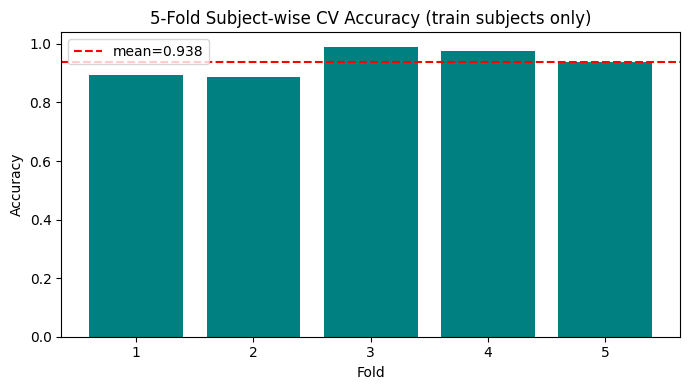

In [ ]:
gkf = GroupKFold(n_splits=5)
cv_accuracies, cv_f1s = [], []
for fold, (tr_i, va_i) in enumerate(gkf.split(R_full, y_full, groups=S_full), start=1):
    tf.keras.utils.set_random_seed(SEED)
    tr_in = {'raw': Rn(R_full[tr_i]), 'feat': Fn(F_full[tr_i])}
    va_in = {'raw': Rn(R_full[va_i]), 'feat': Fn(F_full[va_i])}
    m = compile_model(build_hybrid(dropout=BEST_DROPOUT), lr=BEST_LR)
    m.fit(tr_in, oh(y_full[tr_i]), validation_data=(va_in, oh(y_full[va_i])), epochs=15, batch_size=64, verbose=0,
          callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)])
    yp = np.argmax(m.predict(va_in, verbose=0), axis=1)
    acc = accuracy_score(y_full[va_i], yp)
    _, _, f1, _ = precision_recall_fscore_support(y_full[va_i], yp, average='macro', zero_division=0)
    cv_accuracies.append(acc); cv_f1s.append(f1)
    print(f"Fold {fold}: accuracy={acc:.4f}, macro F1={f1:.4f}")

print(f"\nCV Accuracy: {np.mean(cv_accuracies):.4f} +/- {np.std(cv_accuracies):.4f}")
print(f"CV Macro F1: {np.mean(cv_f1s):.4f} +/- {np.std(cv_f1s):.4f}")

plt.figure(figsize=(7,4))
plt.bar(range(1,6), cv_accuracies, color='teal')
plt.axhline(np.mean(cv_accuracies), color='red', linestyle='--', label=f"mean={np.mean(cv_accuracies):.3f}")
plt.xlabel("Fold"); plt.ylabel("Accuracy"); plt.title("5-Fold Subject-wise CV Accuracy (train subjects only)"); plt.legend()
plt.tight_layout(); plt.savefig("06_cv_accuracy.png", dpi=150); plt.show()

## 11. Training Procedure

Forward pass -> loss -> backprop -> Adam step -> repeat, monitored on the subject-held-out validation set.
- **Loss:** categorical cross-entropy + label smoothing 0.05
- **Augmentation:** raw-signal jitter/scale/shift on the training stream only
- **EarlyStopping** on validation loss (restores best weights) and **ReduceLROnPlateau**
- **The test set is not used for any training decision.**


=== Training CNN_Baseline ===
Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: raw
Received: inputs=['Tensor(shape=(None, 128, 9))']
  warnings.warn(msg)


92/92 - 9s - 101ms/step - accuracy: 0.8672 - loss: 0.5925 - val_accuracy: 0.9504 - val_loss: 0.8411 - learning_rate: 0.0010
Epoch 2/50
92/92 - 4s - 44ms/step - accuracy: 0.9342 - loss: 0.4202 - val_accuracy: 0.9633 - val_loss: 0.5185 - learning_rate: 0.0010
Epoch 3/50
92/92 - 4s - 46ms/step - accuracy: 0.9451 - loss: 0.4004 - val_accuracy: 0.9681 - val_loss: 0.4089 - learning_rate: 0.0010
Epoch 4/50
92/92 - 5s - 57ms/step - accuracy: 0.9451 - loss: 0.3938 - val_accuracy: 0.9674 - val_loss: 0.3779 - learning_rate: 0.0010
Epoch 5/50
92/92 - 4s - 45ms/step - accuracy: 0.9536 - loss: 0.3783 - val_accuracy: 0.9559 - val_loss: 0.3613 - learning_rate: 0.0010
Epoch 6/50
92/92 - 6s - 70ms/step - accuracy: 0.9498 - loss: 0.3795 - val_accuracy: 0.9701 - val_loss: 0.3737 - learning_rate: 0.0010
Epoch 7/50
92/92 - 9s - 97ms/step - accuracy: 0.9493 - loss: 0.3790 - val_accuracy: 0.9735 - val_loss: 0.3890 - learning_rate: 0.0010
Epoch 8/50
92/92 - 6s - 70ms/step - accuracy: 0.9473 - loss: 0.3748 - va

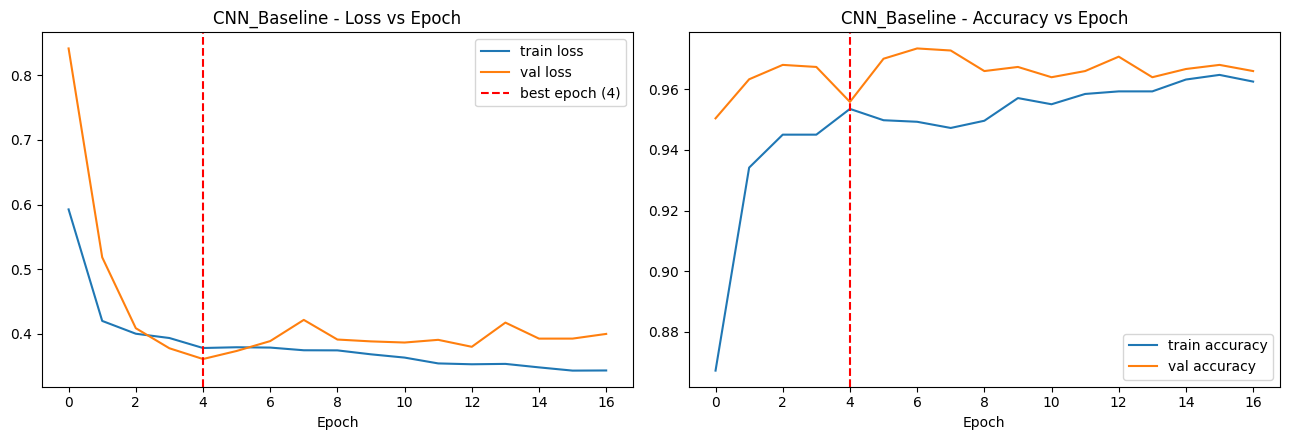

CNN_Baseline trained in 101.6s over 17 epochs

=== Training CNN_BiLSTM_Raw ===
Epoch 1/70
92/92 - 53s - 576ms/step - accuracy: 0.8672 - loss: 0.6603 - val_accuracy: 0.9654 - val_loss: 0.4596 - learning_rate: 0.0010
Epoch 2/70
92/92 - 42s - 461ms/step - accuracy: 0.9377 - loss: 0.4831 - val_accuracy: 0.9362 - val_loss: 0.4564 - learning_rate: 0.0010
Epoch 3/70
92/92 - 42s - 462ms/step - accuracy: 0.9411 - loss: 0.4553 - val_accuracy: 0.9674 - val_loss: 0.4289 - learning_rate: 0.0010
Epoch 4/70
92/92 - 83s - 901ms/step - accuracy: 0.9473 - loss: 0.4427 - val_accuracy: 0.9647 - val_loss: 0.4503 - learning_rate: 0.0010
Epoch 5/70
92/92 - 84s - 912ms/step - accuracy: 0.9480 - loss: 0.4269 - val_accuracy: 0.9504 - val_loss: 0.3814 - learning_rate: 0.0010
Epoch 6/70
92/92 - 79s - 854ms/step - accuracy: 0.9478 - loss: 0.4246 - val_accuracy: 0.9701 - val_loss: 0.4160 - learning_rate: 0.0010
Epoch 7/70
92/92 - 84s - 916ms/step - accuracy: 0.9493 - loss: 0.4180 - val_accuracy: 0.9701 - val_loss: 

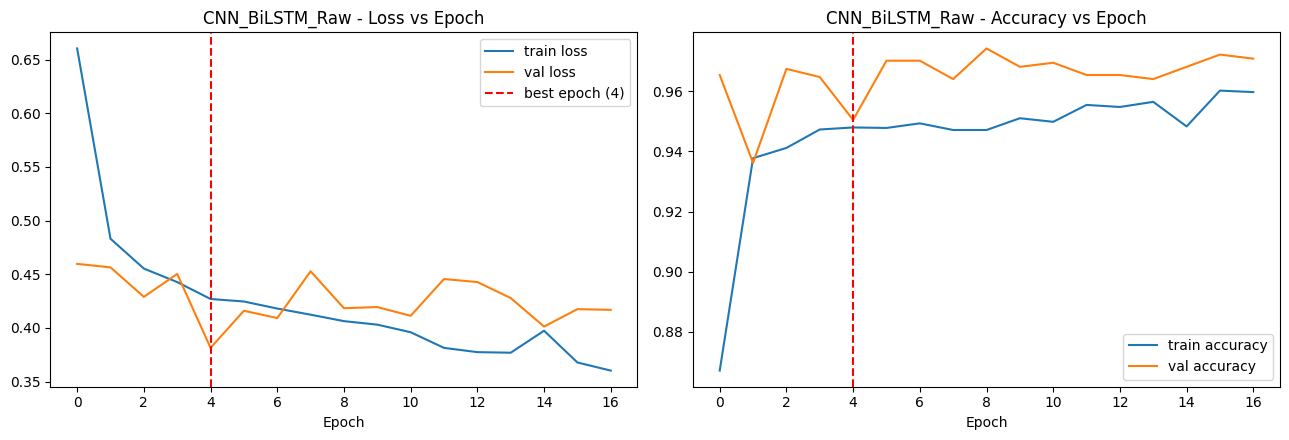

CNN_BiLSTM_Raw trained in 1099.8s over 17 epochs

=== Training Hybrid_CNN_BiLSTM ===
Epoch 1/80
92/92 - 31s - 336ms/step - accuracy: 0.8491 - loss: 0.7282 - val_accuracy: 0.9640 - val_loss: 0.5894 - learning_rate: 5.0000e-04
Epoch 2/80
92/92 - 39s - 423ms/step - accuracy: 0.9505 - loss: 0.5053 - val_accuracy: 0.9674 - val_loss: 0.4892 - learning_rate: 5.0000e-04
Epoch 3/80
92/92 - 23s - 247ms/step - accuracy: 0.9638 - loss: 0.4761 - val_accuracy: 0.9708 - val_loss: 0.4750 - learning_rate: 5.0000e-04
Epoch 4/80
92/92 - 40s - 437ms/step - accuracy: 0.9709 - loss: 0.4523 - val_accuracy: 0.9708 - val_loss: 0.4545 - learning_rate: 5.0000e-04
Epoch 5/80
92/92 - 22s - 244ms/step - accuracy: 0.9762 - loss: 0.4348 - val_accuracy: 0.9640 - val_loss: 0.4428 - learning_rate: 5.0000e-04
Epoch 6/80
92/92 - 21s - 227ms/step - accuracy: 0.9801 - loss: 0.4232 - val_accuracy: 0.9722 - val_loss: 0.4329 - learning_rate: 5.0000e-04
Epoch 7/80
92/92 - 23s - 247ms/step - accuracy: 0.9849 - loss: 0.4127 - val

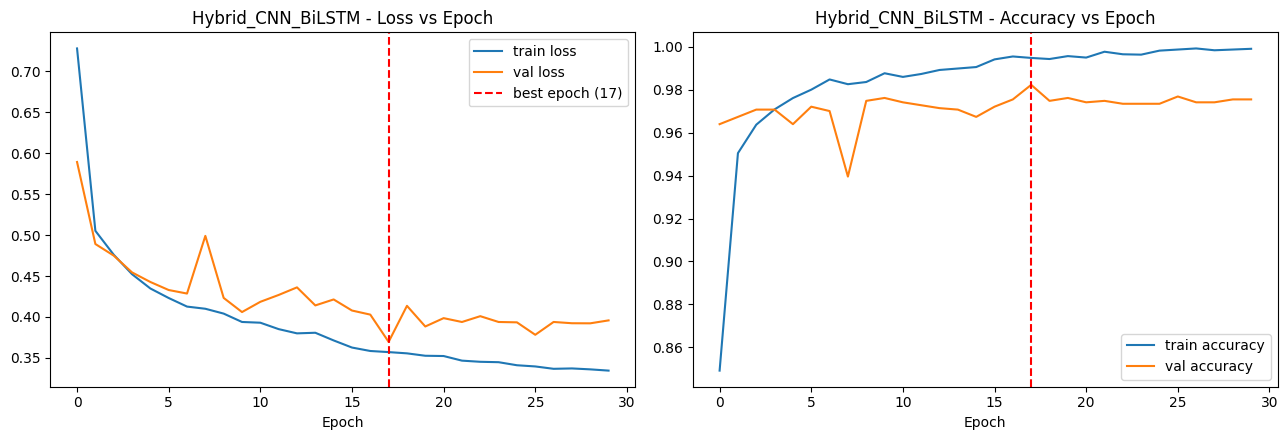

Hybrid_CNN_BiLSTM trained in 866.4s over 30 epochs


In [ ]:
def train_model(model, train_in, y_tr_oh, val_in, y_v_oh, lr=1e-3, epochs=80, batch_size=64, augment=True):
    compile_model(model, lr=lr)
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5),
    ]
    train_ds = make_dataset(train_in, y_tr_oh, batch_size, training=True, augment=augment)
    val_ds = make_dataset(val_in, y_v_oh, batch_size, training=False)
    start = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks, verbose=2)
    return history, time.time() - start

def plot_history(history, name):
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    best_epoch = int(np.argmin(history.history['val_loss']))
    ax[0].plot(history.history['loss'], label='train loss'); ax[0].plot(history.history['val_loss'], label='val loss')
    ax[0].axvline(best_epoch, color='red', linestyle='--', label=f'best epoch ({best_epoch})')
    ax[0].set_title(f'{name} - Loss vs Epoch'); ax[0].set_xlabel("Epoch"); ax[0].legend()
    ax[1].plot(history.history['accuracy'], label='train accuracy'); ax[1].plot(history.history['val_accuracy'], label='val accuracy')
    ax[1].axvline(best_epoch, color='red', linestyle='--')
    ax[1].set_title(f'{name} - Accuracy vs Epoch'); ax[1].set_xlabel("Epoch"); ax[1].legend()
    plt.tight_layout(); plt.savefig(f"07_history_{name}.png", dpi=150); plt.show()

results, compute_cost = {}, []
RAW_TRAIN, RAW_VAL, RAW_TEST = {'raw': R_train_n}, {'raw': R_val_n}, {'raw': R_test_n}

def run(name, builder, tr_in, va_in, augment, lr, epochs=80):
    tf.keras.utils.set_random_seed(SEED)
    model = builder()
    print(f"\n=== Training {name} ===")
    history, elapsed = train_model(model, tr_in, y_train_oh, va_in, y_val_oh, lr=lr, epochs=epochs, augment=augment)
    plot_history(history, name)
    results[name] = {"model": model, "history": history}
    compute_cost.append({"Model": name, "Trainable Params": model.count_params(),
                         "Training Time (s)": round(elapsed, 1), "Epochs Run": len(history.history['loss'])})
    print(f"{name} trained in {elapsed:.1f}s over {len(history.history['loss'])} epochs")

run("CNN_Baseline", build_cnn_baseline, RAW_TRAIN, RAW_VAL, augment=False, lr=1e-3, epochs=50)
run("CNN_BiLSTM_Raw", build_cnn_bilstm_raw, RAW_TRAIN, RAW_VAL, augment=True, lr=1e-3, epochs=70)
run("Hybrid_CNN_BiLSTM", lambda: build_hybrid(dropout=BEST_DROPOUT), TRAIN_IN, VAL_IN, augment=True, lr=BEST_LR, epochs=80)

## 12. Seed Ensemble

The hybrid model is retrained from different random initializations (seeds in `ENSEMBLE_SEEDS`, the first is the model above) and the softmax outputs are **averaged**. Each member early-stops on a subject-held-out validation split (a different subject split per seed, which also adds diversity); the test set plays no role in training.

In [ ]:
ensemble_models, ensemble_seeds = [results["Hybrid_CNN_BiLSTM"]["model"]], [ENSEMBLE_SEEDS[0]]

for seed in ENSEMBLE_SEEDS[1:]:
    tf.keras.utils.set_random_seed(seed)
    tr_i, va_i = next(GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=seed).split(R_full, y_full, groups=S_full))
    tr_in = {'raw': Rn(R_full[tr_i]), 'feat': Fn(F_full[tr_i])}
    va_in = {'raw': Rn(R_full[va_i]), 'feat': Fn(F_full[va_i])}
    m = build_hybrid(dropout=BEST_DROPOUT)
    print(f"\n=== Training Hybrid (seed={seed}) for ensemble ===")
    h, elapsed = train_model(m, tr_in, oh(y_full[tr_i]), va_in, oh(y_full[va_i]), lr=BEST_LR, epochs=80, augment=True)
    ensemble_models.append(m); ensemble_seeds.append(seed)
    compute_cost.append({"Model": f"Hybrid_seed{seed}", "Trainable Params": m.count_params(),
                         "Training Time (s)": round(elapsed, 1), "Epochs Run": len(h.history['loss'])})
    print(f"seed={seed}: {elapsed:.1f}s, {len(h.history['loss'])} epochs, best val_accuracy={max(h.history['val_accuracy']):.4f}")

def ensemble_predict_proba(models_list, inputs):
    return np.mean([m.predict(inputs, verbose=0) for m in models_list], axis=0)

print(f"\nEnsemble of {len(ensemble_models)} hybrid models (seeds {ensemble_seeds}) ready.")


=== Training Hybrid (seed=7) for ensemble ===
Epoch 1/80
95/95 - 33s - 344ms/step - accuracy: 0.8685 - loss: 0.6839 - val_accuracy: 0.9112 - val_loss: 0.6442 - learning_rate: 5.0000e-04
Epoch 2/80
95/95 - 24s - 255ms/step - accuracy: 0.9638 - loss: 0.4769 - val_accuracy: 0.9250 - val_loss: 0.5852 - learning_rate: 5.0000e-04
Epoch 3/80
95/95 - 40s - 420ms/step - accuracy: 0.9768 - loss: 0.4475 - val_accuracy: 0.9326 - val_loss: 0.5476 - learning_rate: 5.0000e-04
Epoch 4/80
95/95 - 41s - 434ms/step - accuracy: 0.9797 - loss: 0.4323 - val_accuracy: 0.9288 - val_loss: 0.5582 - learning_rate: 5.0000e-04
Epoch 5/80
95/95 - 23s - 239ms/step - accuracy: 0.9848 - loss: 0.4191 - val_accuracy: 0.9204 - val_loss: 0.5725 - learning_rate: 5.0000e-04
Epoch 6/80
95/95 - 23s - 239ms/step - accuracy: 0.9853 - loss: 0.4104 - val_accuracy: 0.9204 - val_loss: 0.5844 - learning_rate: 5.0000e-04
Epoch 7/80
95/95 - 20s - 216ms/step - accuracy: 0.9883 - loss: 0.4031 - val_accuracy: 0.9319 - val_loss: 0.5405 -

## 13. Gradient Descent Convergence Analysis

L2 norm of the gradient per epoch on the CNN baseline with a manual `tf.GradientTape` loop: as training approaches a minimum the gradient norm shrinks - the mechanism early stopping relies on.

Epoch 1/25 - train_loss=0.5339, val_loss=0.5470, grad_norm=1.4527
Epoch 2/25 - train_loss=0.2037, val_loss=0.2307, grad_norm=1.0907
Epoch 3/25 - train_loss=0.1324, val_loss=0.1196, grad_norm=0.8617
Epoch 4/25 - train_loss=0.1153, val_loss=0.1147, grad_norm=0.7698
Epoch 5/25 - train_loss=0.1088, val_loss=0.1336, grad_norm=0.7584
Epoch 6/25 - train_loss=0.1045, val_loss=0.0983, grad_norm=0.8451
Epoch 7/25 - train_loss=0.1042, val_loss=0.1265, grad_norm=0.7777
Epoch 8/25 - train_loss=0.0992, val_loss=0.1328, grad_norm=0.7290
Epoch 9/25 - train_loss=0.1173, val_loss=0.0988, grad_norm=0.8038
Epoch 10/25 - train_loss=0.0997, val_loss=0.1206, grad_norm=0.8491
Epoch 11/25 - train_loss=0.0919, val_loss=0.1286, grad_norm=0.7113
Epoch 12/25 - train_loss=0.0926, val_loss=0.1684, grad_norm=0.7739
Epoch 13/25 - train_loss=0.0890, val_loss=0.1637, grad_norm=0.7426
Epoch 14/25 - train_loss=0.0844, val_loss=0.1111, grad_norm=1.0166
Epoch 15/25 - train_loss=0.0810, val_loss=0.0947, grad_norm=0.7833
Epoc

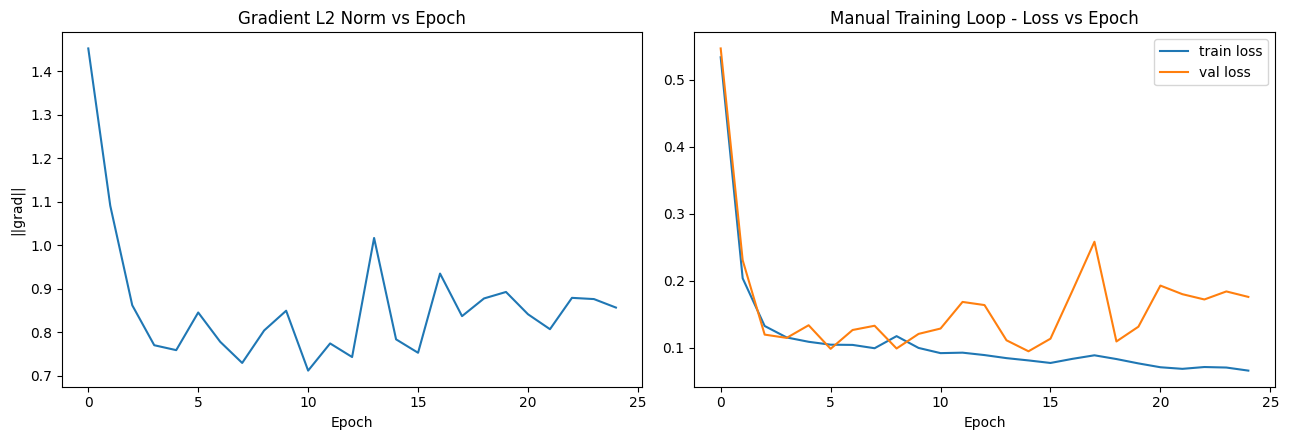

In [ ]:
def manual_training_loop(model, X_tr, y_tr, X_v, y_v, epochs=25, batch_size=64, lr=1e-3):
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    loss_fn = tf.keras.losses.CategoricalCrossentropy()
    grad_norms, train_losses, val_losses = [], [], []
    n_batches = len(X_tr) // batch_size
    for epoch in range(epochs):
        epoch_norms = []
        idx = np.random.permutation(len(X_tr))
        for b in range(n_batches):
            bi = idx[b*batch_size:(b+1)*batch_size]
            with tf.GradientTape() as tape:
                loss = loss_fn(y_tr[bi], model(X_tr[bi], training=True))
            grads = tape.gradient(loss, model.trainable_variables)
            epoch_norms.append(float(tf.sqrt(sum(tf.reduce_sum(tf.square(g)) for g in grads if g is not None))))
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
        train_losses.append(float(loss_fn(y_tr, model(X_tr, training=False))))
        val_losses.append(float(loss_fn(y_v, model(X_v, training=False))))
        grad_norms.append(np.mean(epoch_norms))
        print(f"Epoch {epoch+1}/{epochs} - train_loss={train_losses[-1]:.4f}, val_loss={val_losses[-1]:.4f}, grad_norm={grad_norms[-1]:.4f}")
    return grad_norms, train_losses, val_losses

grad_model = build_cnn_baseline()
grad_model(R_train_n[:2])
grad_norms, gd_train_losses, gd_val_losses = manual_training_loop(grad_model, R_train_n, y_train_oh, R_val_n, y_val_oh)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(grad_norms); ax[0].set_title("Gradient L2 Norm vs Epoch"); ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("||grad||")
ax[1].plot(gd_train_losses, label='train loss'); ax[1].plot(gd_val_losses, label='val loss')
ax[1].set_title("Manual Training Loop - Loss vs Epoch"); ax[1].set_xlabel("Epoch"); ax[1].legend()
plt.tight_layout(); plt.savefig("08_gradient_convergence.png", dpi=150); plt.show()

## 14. Evaluation (CO3 - Required Metrics)

Confusion matrix, accuracy, precision, recall, macro-F1, specificity, ROC-AUC and ROC curves on the **official, untouched UCI HAR test set** (different subjects from train/validation).

/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: raw
Received: inputs=['Tensor(shape=(32, 128, 9))']
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: raw
Received: inputs=['Tensor(shape=(None, 128, 9))']
  warnings.warn(msg)



=== CNN_Baseline - Test Set Results ===
Accuracy:    0.8996
Precision:   0.9138
Recall:      0.9006
F1 (macro):  0.8977
Specificity: 0.9798
ROC-AUC:     0.9912
                    precision    recall  f1-score   support

           WALKING       1.00      0.98      0.99       496
  WALKING_UPSTAIRS       0.95      0.95      0.95       471
WALKING_DOWNSTAIRS       0.92      1.00      0.96       420
           SITTING       0.91      0.57      0.70       491
          STANDING       0.71      0.95      0.81       532
            LAYING       0.99      0.96      0.97       537

          accuracy                           0.90      2947
         macro avg       0.91      0.90      0.90      2947
      weighted avg       0.91      0.90      0.90      2947



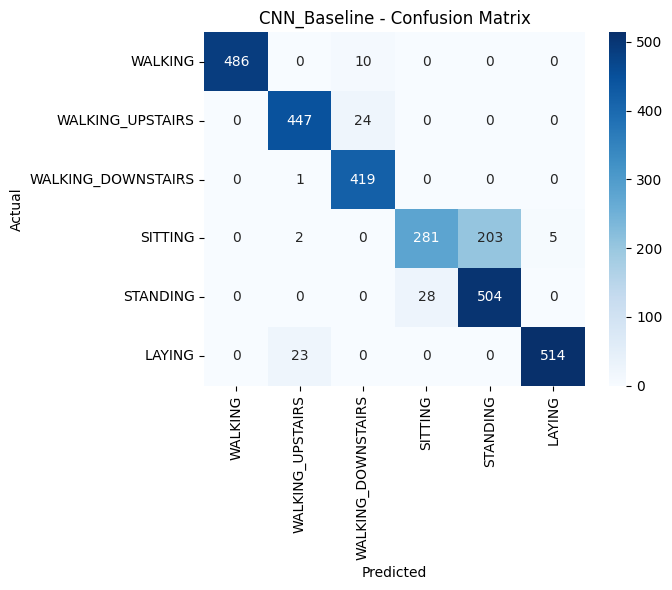

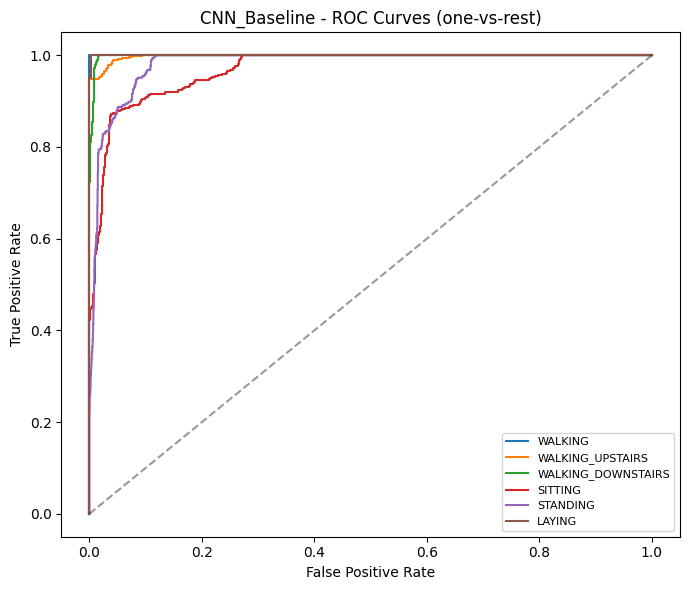

/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: raw
Received: inputs=['Tensor(shape=(32, 128, 9))']
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: raw
Received: inputs=['Tensor(shape=(None, 128, 9))']
  warnings.warn(msg)



=== CNN_BiLSTM_Raw - Test Set Results ===
Accuracy:    0.8880
Precision:   0.9058
Recall:      0.8889
F1 (macro):  0.8845
Specificity: 0.9774
ROC-AUC:     0.9901
                    precision    recall  f1-score   support

           WALKING       1.00      0.95      0.97       496
  WALKING_UPSTAIRS       0.96      0.95      0.96       471
WALKING_DOWNSTAIRS       0.90      1.00      0.95       420
           SITTING       0.90      0.51      0.65       491
          STANDING       0.69      0.95      0.80       532
            LAYING       0.99      0.97      0.98       537

          accuracy                           0.89      2947
         macro avg       0.91      0.89      0.88      2947
      weighted avg       0.90      0.89      0.88      2947



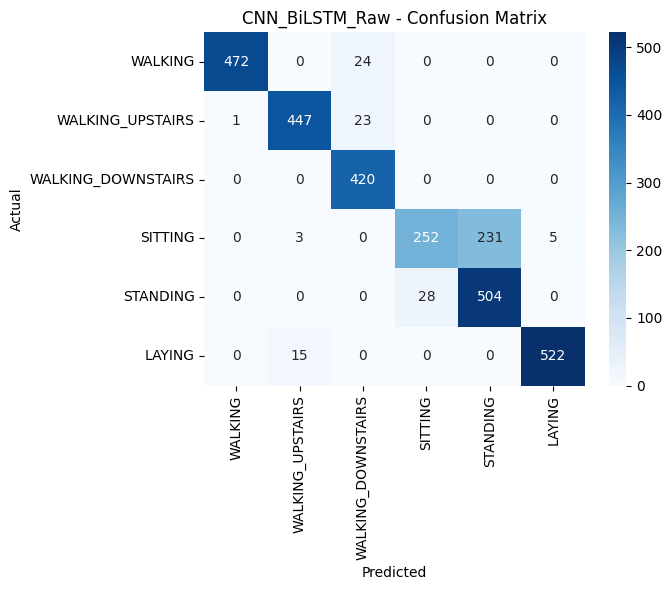

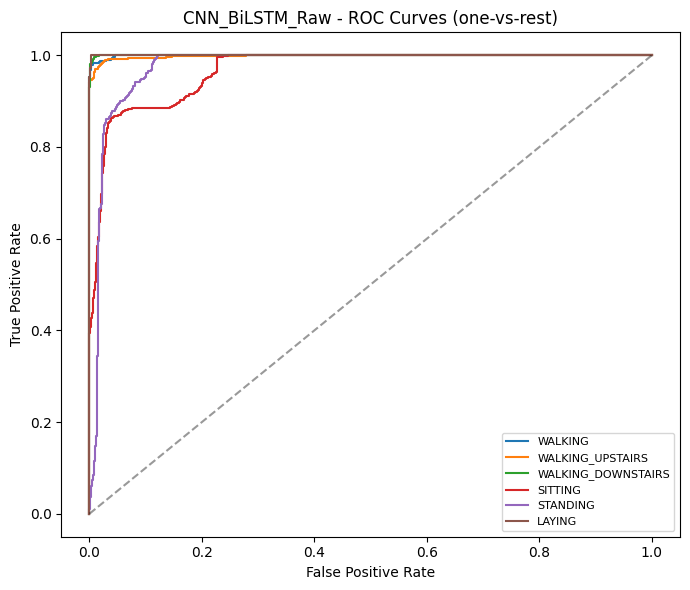


=== Hybrid_single_seed - Test Set Results ===
Accuracy:    0.9488
Precision:   0.9524
Recall:      0.9488
F1 (macro):  0.9484
Specificity: 0.9897
ROC-AUC:     0.9962
                    precision    recall  f1-score   support

           WALKING       1.00      0.98      0.99       496
  WALKING_UPSTAIRS       0.99      0.95      0.97       471
WALKING_DOWNSTAIRS       0.93      1.00      0.96       420
           SITTING       0.96      0.80      0.87       491
          STANDING       0.85      0.97      0.91       532
            LAYING       0.99      1.00      0.99       537

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947



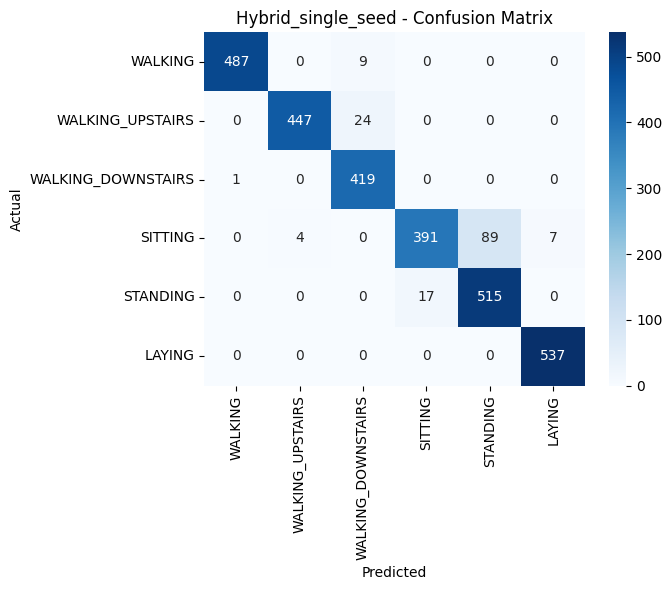

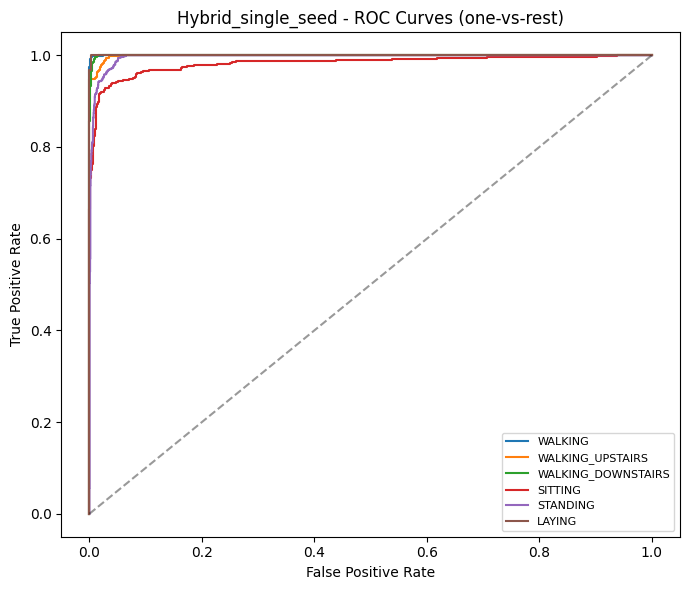


=== Hybrid_Ensemble - Test Set Results ===
Accuracy:    0.9569
Precision:   0.9580
Recall:      0.9573
F1 (macro):  0.9570
Specificity: 0.9914
ROC-AUC:     0.9985
                    precision    recall  f1-score   support

           WALKING       1.00      1.00      1.00       496
  WALKING_UPSTAIRS       0.99      0.95      0.97       471
WALKING_DOWNSTAIRS       0.94      1.00      0.97       420
           SITTING       0.94      0.85      0.89       491
          STANDING       0.89      0.95      0.92       532
            LAYING       0.99      1.00      1.00       537

          accuracy                           0.96      2947
         macro avg       0.96      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947



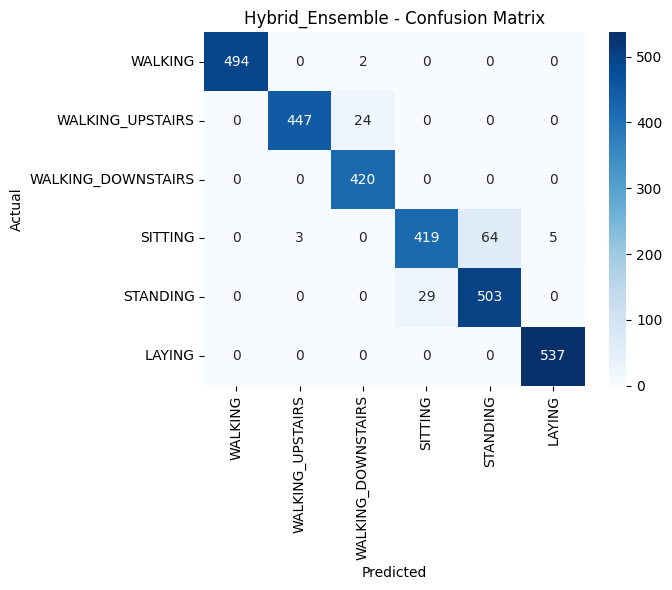

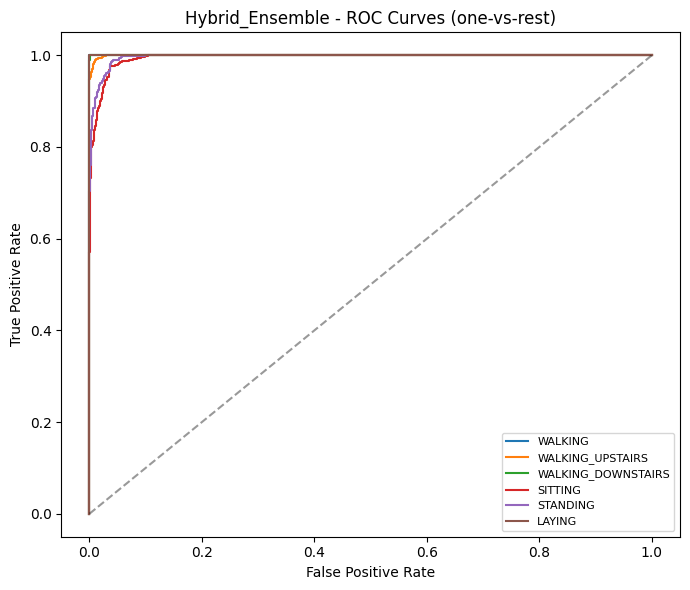

In [ ]:
def evaluate_model(y_prob, y_te_int, name):
    y_pred = np.argmax(y_prob, axis=1)
    acc = accuracy_score(y_te_int, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_te_int, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_te_int, y_pred)
    spec = []
    for i in range(num_classes):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i]); fp = cm[:, i].sum() - cm[i, i]
        spec.append(tn / (tn + fp + 1e-8))
    y_bin = label_binarize(y_te_int, classes=list(range(num_classes)))
    auc = roc_auc_score(y_bin, y_prob, average='macro', multi_class='ovr')

    print(f"\n=== {name} - Test Set Results ===")
    print(f"Accuracy:    {acc:.4f}\nPrecision:   {precision:.4f}\nRecall:      {recall:.4f}")
    print(f"F1 (macro):  {f1:.4f}\nSpecificity: {np.mean(spec):.4f}\nROC-AUC:     {auc:.4f}")
    print(classification_report(y_te_int, y_pred, target_names=ACTIVITY_NAMES, zero_division=0))

    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ACTIVITY_NAMES, yticklabels=ACTIVITY_NAMES)
    plt.title(f'{name} - Confusion Matrix'); plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.savefig(f"09_confusion_matrix_{name}.png", dpi=150); plt.show()

    plt.figure(figsize=(7,6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i]); plt.plot(fpr, tpr, label=ACTIVITY_NAMES[i])
    plt.plot([0,1],[0,1],'k--', alpha=0.4); plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"{name} - ROC Curves (one-vs-rest)"); plt.legend(fontsize=8)
    plt.tight_layout(); plt.savefig(f"10_roc_{name}.png", dpi=150); plt.show()
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1, "specificity": float(np.mean(spec)), "auc": auc}

eval_results = {}
eval_results["CNN_Baseline"]      = evaluate_model(results["CNN_Baseline"]["model"].predict(RAW_TEST, verbose=0), y_test, "CNN_Baseline")
eval_results["CNN_BiLSTM_Raw"]    = evaluate_model(results["CNN_BiLSTM_Raw"]["model"].predict(RAW_TEST, verbose=0), y_test, "CNN_BiLSTM_Raw")
eval_results["Hybrid_single"]     = evaluate_model(results["Hybrid_CNN_BiLSTM"]["model"].predict(TEST_IN, verbose=0), y_test, "Hybrid_single_seed")
eval_results["Hybrid_Ensemble"]   = evaluate_model(ensemble_predict_proba(ensemble_models, TEST_IN), y_test, "Hybrid_Ensemble")

## 15. Computational Cost & Trainable Parameters

In [ ]:
cost_df = pd.DataFrame(compute_cost)
cost_df.to_csv("computational_cost.csv", index=False)
display(cost_df)

,Model,Trainable Params,Training Time (s),Epochs Run
0,CNN_Baseline,53446,101.6,17
1,CNN_BiLSTM_Raw,393126,1099.8,17
2,Hybrid_CNN_BiLSTM,376390,866.4,30
3,Hybrid_seed7,376390,599.3,19
4,Hybrid_seed123,376390,532.7,17
5,Hybrid_seed1,376390,975.4,34
6,Hybrid_seed2,376390,1430.2,54


## 16. Ablation Study (CO5 - Innovation Evidence)

Each row adds one ingredient, so the table shows what the feature branch and the ensemble contribute.

In [ ]:
ablation_df = pd.DataFrame({
    "Experiment": ["CNN only (raw)", "CNN + BiLSTM (raw only)", "Hybrid: + 561-feature branch (single seed)", f"Hybrid ensemble (x{len(ensemble_models)})"],
    "BiLSTM": ["No", "Yes", "Yes", "Yes"],
    "561-feature branch": ["No", "No", "Yes", "Yes"],
    "Augmentation": ["No", "Yes", "Yes", "Yes"],
    "Seed Ensemble": ["No", "No", "No", f"Yes (x{len(ensemble_models)})"],
    "Accuracy": [eval_results[k]["accuracy"] for k in ["CNN_Baseline", "CNN_BiLSTM_Raw", "Hybrid_single", "Hybrid_Ensemble"]],
    "F1 (macro)": [eval_results[k]["f1"] for k in ["CNN_Baseline", "CNN_BiLSTM_Raw", "Hybrid_single", "Hybrid_Ensemble"]],
})
ablation_df.to_csv("ablation_results.csv", index=False)
display(ablation_df)

,Experiment,BiLSTM,561-feature branch,Augmentation,Seed Ensemble,Accuracy,F1 (macro)
0,CNN only (raw),No,No,No,No,0.899559,0.897717
1,CNN + BiLSTM (raw only),Yes,No,Yes,No,0.888022,0.884470
2,Hybrid: + 561-feature branch (single seed),Yes,Yes,Yes,No,0.948761,0.948425
3,Hybrid ensemble (x5),Yes,Yes,Yes,Yes (x5),0.956905,0.956971


## 17. Comparative Analysis vs. Published Literature (CO4)

Literature figures are **as reported by the cited papers**; evaluation protocols differ between papers (official split vs. pooled k-fold, raw signals vs. the 561 features), so treat them as context, not a like-for-like ranking. The "this work" rows come from the cells above.

- Stacked LSTM ~93.1% - arXiv:2505.06730
- LSTM-CNN, Xia et al. ~95.78% - IEEE Access 2020, doi:10.1109/ACCESS.2020.2982225
- LSTM-CNN, Lyu et al. ~98.4% - arXiv:2101.01665 (protocol not verified here)

> Many ~99% figures for UCI HAR come from pooled k-fold (windows of the same subject in train and test) or from the 561 features rather than raw signals. This notebook uses the **official subject-independent split** and reports the test set once, after all training decisions.

In [ ]:
h1, h2 = eval_results["Hybrid_single"], eval_results["Hybrid_Ensemble"]
comparison_df = pd.DataFrame({
    "Model": ["Stacked LSTM (literature)", "LSTM-CNN, Xia et al. (literature)", "LSTM-CNN, Lyu et al. (literature)",
              "CNN baseline, raw (this work)", "CNN+BiLSTM, raw only (this work)",
              "Hybrid single seed (this work)", f"Hybrid x{len(ensemble_models)} ensemble (this work, proposed)"],
    "Accuracy": [0.931, 0.9578, 0.984, eval_results["CNN_Baseline"]["accuracy"], eval_results["CNN_BiLSTM_Raw"]["accuracy"], h1["accuracy"], h2["accuracy"]],
    "F1": [None, None, None, eval_results["CNN_Baseline"]["f1"], eval_results["CNN_BiLSTM_Raw"]["f1"], h1["f1"], h2["f1"]],
    "AUC": [None, None, None, eval_results["CNN_Baseline"]["auc"], eval_results["CNN_BiLSTM_Raw"]["auc"], h1["auc"], h2["auc"]],
    "Source": ["arXiv:2505.06730", "IEEE Access 2020", "arXiv:2101.01665", "This work", "This work", "This work", "This work"],
})
comparison_df.to_csv("sota_comparison.csv", index=False)
display(comparison_df)

,Model,Accuracy,F1,AUC,Source
0,Stacked LSTM (literature),0.931000,NaN,NaN,arXiv:2505.06730
1,"LSTM-CNN, Xia et al. (literature)",0.957800,NaN,NaN,IEEE Access 2020
2,"LSTM-CNN, Lyu et al. (literature)",0.984000,NaN,NaN,arXiv:2101.01665
3,"CNN baseline, raw (this work)",0.899559,0.897717,0.991208,This work
4,"CNN+BiLSTM, raw only (this work)",0.888022,0.884470,0.990056,This work
5,Hybrid single seed (this work),0.948761,0.948425,0.996160,This work
6,"Hybrid x5 ensemble (this work, proposed)",0.956905,0.956971,0.998470,This work


## 18. Save Everything for Submission

In [ ]:
import shutil
os.makedirs("results", exist_ok=True); os.makedirs("models", exist_ok=True)
for f in os.listdir("."):
    if f.endswith(".png") or f.endswith(".csv"):
        shutil.move(f, os.path.join("results", f))
for name, r in results.items():
    r["model"].save(f"models/{name}.keras")
for m, s in zip(ensemble_models, ensemble_seeds):
    m.save(f"models/Hybrid_seed{s}.keras")
np.savez("models/preprocessing_stats.npz", r_mean=r_mean, r_std=r_std, f_mean=f_mean, f_std=f_std)
print("Saved figures/CSVs to results/, models + preprocessing stats to models/")
print("results/:", sorted(os.listdir("results"))); print("models/:", sorted(os.listdir("models")))

Saved figures/CSVs to results/, models + preprocessing stats to models/
results/: ['01_class_distribution.png', '02_sample_signals_per_activity.png', '03_channel_correlation.png', '04_magnitude_boxplot.png', '05_bias_variance_demo.png', '06_cv_accuracy.png', '07_history_CNN_Baseline.png', '07_history_CNN_BiLSTM_Raw.png', '07_history_Hybrid_CNN_BiLSTM.png', '08_gradient_convergence.png', '09_confusion_matrix_CNN_Baseline.png', '09_confusion_matrix_CNN_BiLSTM_Raw.png', '09_confusion_matrix_Hybrid_Ensemble.png', '09_confusion_matrix_Hybrid_single_seed.png', '10_roc_CNN_Baseline.png', '10_roc_CNN_BiLSTM_Raw.png', '10_roc_Hybrid_Ensemble.png', '10_roc_Hybrid_single_seed.png', 'ablation_results.csv', 'computational_cost.csv', 'sota_comparison.csv']
models/: ['CNN_Baseline.keras', 'CNN_BiLSTM_Raw.keras', 'Hybrid_CNN_BiLSTM.keras', 'Hybrid_seed1.keras', 'Hybrid_seed123.keras', 'Hybrid_seed2.keras', 'Hybrid_seed42.keras', 'Hybrid_seed7.keras', 'preprocessing_stats.npz']


## 19. Prediction Cell - inference with the final proposed model (hybrid ensemble)

In [ ]:
def predict_activity_ensemble(models_list, R_window, F_window, true_label=None):
    '''R_window: (N,128,9) normalized raw windows; F_window: (N,561) normalized features. Returns labels + probabilities.'''
    probs = ensemble_predict_proba(models_list, {'raw': R_window, 'feat': F_window})
    pred_idx, conf = np.argmax(probs, axis=1), np.max(probs, axis=1)
    for i in range(len(pred_idx)):
        line = f"Predicted: {ACTIVITY_NAMES[pred_idx[i]]}  (confidence: {conf[i]*100:.2f}%)"
        if true_label is not None:
            ok = pred_idx[i] == true_label[i]
            line += f"   |   Actual: {ACTIVITY_NAMES[true_label[i]]}  {'OK' if ok else 'WRONG'}"
        print(line)
    return pred_idx, probs

print("=== Batch prediction on 10 random test samples (ensemble) ===")
bi = np.random.choice(len(R_test_n), 10, replace=False)
_ = predict_activity_ensemble(ensemble_models, R_test_n[bi], F_test_n[bi], true_label=y_test[bi])

=== Batch prediction on 10 random test samples (ensemble) ===
Predicted: LAYING  (confidence: 96.67%)   |   Actual: LAYING  OK
Predicted: STANDING  (confidence: 67.19%)   |   Actual: STANDING  OK
Predicted: SITTING  (confidence: 94.79%)   |   Actual: SITTING  OK
Predicted: LAYING  (confidence: 96.77%)   |   Actual: LAYING  OK
Predicted: LAYING  (confidence: 61.91%)   |   Actual: LAYING  OK
Predicted: SITTING  (confidence: 97.59%)   |   Actual: SITTING  OK
Predicted: LAYING  (confidence: 96.20%)   |   Actual: LAYING  OK
Predicted: STANDING  (confidence: 97.20%)   |   Actual: STANDING  OK
Predicted: WALKING  (confidence: 93.93%)   |   Actual: WALKING  OK
Predicted: WALKING  (confidence: 97.64%)   |   Actual: WALKING  OK


In [ ]:
!pip freeze | grep -iE "tensorflow|scikit-learn|pandas|matplotlib|seaborn|numpy"

geopandas==1.1.4
matplotlib==3.10.0
matplotlib-inline==0.2.2
matplotlib-venn==1.1.2
numpy==2.1.3
pandas==2.2.3
pandas-datareader==0.11.1
pandas-gbq==0.30.0
pandas-stubs==2.2.3.250527
scikit-learn==1.6.1
seaborn==0.13.2
sklearn-pandas==2.2.0
tensorflow==2.20.0
tensorflow-datasets==4.9.10
tensorflow-hub==0.16.1
tensorflow-metadata==1.21.0
tensorflow-probability==0.25.0
tensorflow-text==2.20.1
